# Privacy-Preserving Bug Severity Prediction in Federated Software Repositories Using TF-IDF Features and Residual MLP

---

---
## Section 0 — Install Dependencies

In [ ]:
# ── Cell 1: Install Dependencies ────────────────────────────────────────────

!pip install -q flwr torch datasets pandas numpy matplotlib scikit-learn seaborn scipy

# ── Imports ─────────────────────────────────────────────────────────────────
import flwr as fl
import torch

print("=" * 70)
print(" Environment Ready")
print("=" * 70)
print(f"Flower Version : {fl.__version__}")
print(f"PyTorch Version: {torch.__version__}")
print(f"GPU Available  : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU Name       : {torch.cuda.get_device_name(0)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.1/857.1 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 100.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 102.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.3/253.3 kB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 88.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.33.6 which is incompatible.
grpcio-statu

In [ ]:
# ── Cell 2: Imports & Global Config ──────────────────────────────────────────
import warnings; warnings.filterwarnings('ignore')
import re, copy, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from typing import List, Dict, Tuple

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from scipy.sparse import hstack

import flwr as fl

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("Imports OK")
print(f"Device : {DEVICE}")
print(f"PyTorch : {torch.__version__}")
print(f"Flower  : {fl.__version__}")

Imports OK
Device : cuda
PyTorch : 2.11.0+cu128
Flower  : 1.30.0


---
## Section 1 — Hyperparameters

In [ ]:
# ── Cell 3: Hyperparameters ──────────────────────────────────────────────────

# ── FL ───────────────────────────────────────────────────────────────────────
NUM_CLIENTS   = 4
NUM_FL_ROUNDS = 35
LOCAL_EPOCHS  = 8
BATCH_SIZE    = 128
PROXIMAL_MU   = 0.01
WARMUP_ROUNDS = 3

# ── Model / Optimizer ────────────────────────────────────────────────────────
LEARNING_RATE = 5e-4
MIN_LR        = 1e-5

# ── Text Features ────────────────────────────────────────────────────────────
TFIDF_MAX_FEATURES = 5000   # TF-IDF vocabulary

# ── Severity Merging (6 Bugzilla classes → 4 meaningful groups) ──────────────
SEVERITY_MAP = {
    'blocker'     : 'Critical',
    'critical'    : 'Critical',
    'major'       : 'High',
    'normal'      : 'Medium',
    'minor'       : 'Low',
    'trivial'     : 'Low',
}

MERGED_CLASSES_ORDERED = ['Critical', 'High', 'Medium', 'Low']

CAT_COLS = ['Resolution Status', 'Project']

print("Hyperparameters configured")
print(f"FL: {NUM_CLIENTS} clients × {NUM_FL_ROUNDS} rounds × {LOCAL_EPOCHS} local epochs")
print(f"TF-IDF: {TFIDF_MAX_FEATURES} features (unigrams + bigrams)")
print(f"LR: {LEARNING_RATE:.1e} → min {MIN_LR:.1e}  (warmup {WARMUP_ROUNDS} rounds)")

Hyperparameters configured
FL: 4 clients × 35 rounds × 8 local epochs
TF-IDF: 5000 features (unigrams + bigrams)
LR: 5.0e-04 → min 1.0e-05  (warmup 3 rounds)


---
## Section 2 — Load Dataset

In [ ]:
# ── Cell 4: Load Bugzilla Eclipse Dataset ────────────────────────────────────
print("=" * 65)
print("  STEP 1: Loading Bugzilla Eclipse Dataset from HuggingFace")
print("=" * 65)

from datasets import load_dataset
ds = load_dataset("AliArshad/Bugzilla_Eclipse_Bug_Reports_Dataset")

if isinstance(ds, dict):
    df_raw = pd.concat([ds[s].to_pandas() for s in ds.keys()], ignore_index=True)
    print(f"Splits found: {list(ds.keys())}")
else:
    df_raw = ds.to_pandas()

print(f"\nLoaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"Columns: {list(df_raw.columns)}")
print()
print("Original severity label distribution:")
print(df_raw['Severity Label'].value_counts())
print()
# Short text check
df_raw['_wc'] = df_raw['Short Description'].fillna('').str.split().str.len()
print(f"Short Description length (words):")
print(f"mean={df_raw['_wc'].mean():.1f}  median={df_raw['_wc'].median():.0f}  "
      f"p95={df_raw['_wc'].quantile(0.95):.0f}  max={df_raw['_wc'].max()}")
print()

  STEP 1: Loading Bugzilla Eclipse Dataset from HuggingFace


README.md:   0%|          | 0.00/590 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


filtered_data.xlsx%20-%20Sheet1.csv:   0%|          | 0.00/7.72M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/88682 [00:00<?, ? examples/s]

Splits found: ['train']

Loaded: 88,682 rows × 5 columns
Columns: ['Project', 'Bug ID', 'Severity Label', 'Resolution Status', 'Short Description']

Original severity label distribution:
Severity Label
normal      72170
critical     5936
major        4573
minor        3125
trivial      2080
blocker       798
Name: count, dtype: int64

Short Description length (words):
mean=8.1  median=8  p95=15  max=55



---
## Section 3 — Preprocessing & Class Merging

In [ ]:
# ── Cell 5: Preprocessing & Class Merging ────────────────────────────────────
print("=" * 65)
print("  STEP 2: Preprocessing (Clean text, Merge 6→4 classes)")
print("=" * 65)

def clean_text(text: str) -> str:
    if not isinstance(text, str) or not text.strip():
        return ''
    text = text.lower()
    text = re.sub(r'https?://\S+', ' url ', text)
    text = re.sub(r'\b\d+\b', ' NUM ', text)
    text = re.sub(r'[^a-z0-9\s_]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

df = df_raw.copy()
df['Severity Label'] = df['Severity Label'].astype(str).str.lower().str.strip()
df['severity_merged'] = df['Severity Label'].map(SEVERITY_MAP)

# Rich text: title + resolution + project (resolution status carries strong signal!)
df['text'] = (
    df['Short Description'].fillna('') + ' ' +
    df['Resolution Status'].fillna('') + ' ' +
    df['Project'].fillna('')
).apply(clean_text)

# Clean up
df = df.dropna(subset=['severity_merged', 'text'])
df = df[df['text'].str.len() > 3]
df = df[df['severity_merged'].isin(MERGED_CLASSES_ORDERED)]
df = df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

print(f"Clean dataset: {len(df):,} samples")
print()
print("Merged severity distribution (4 classes):")
print(df['severity_merged'].value_counts())
print()
print("Verify merging (original → merged):")
for orig, merged in df.groupby('Severity Label')['severity_merged'].first().items():
    print(f"   {str(orig):15s} → {merged}")

  STEP 2: Preprocessing (Clean text, Merge 6→4 classes)
Clean dataset: 88,682 samples

Merged severity distribution (4 classes):
severity_merged
Medium      72170
Critical     6734
Low          5205
High         4573
Name: count, dtype: int64

Verify merging (original → merged):
   blocker         → Critical
   critical        → Critical
   major           → High
   minor           → Low
   normal          → Medium
   trivial         → Low


---
## Section 4 — Feature Engineering (TF-IDF + One-Hot Categorical)

In [ ]:
# ── Cell 6: Feature Engineering (TF-IDF + One-Hot Categorical) ───────────────
print("=" * 65)
print("  STEP 3: Feature Engineering")
print("=" * 65)
print()

# ── TF-IDF on text ────────────────────────────────────────────────────────────
tfidf = TfidfVectorizer(
    max_features=TFIDF_MAX_FEATURES,
    ngram_range=(1, 2),    # unigrams + bigrams
    sublinear_tf=True,     # log-scaled TF
    min_df=2,
    max_df=0.95,
    analyzer='word',
    strip_accents='unicode',
)
X_tfidf = tfidf.fit_transform(df['text'])
print(f"TF-IDF matrix:       {X_tfidf.shape}  (sparse)")

# ── One-Hot on categorical columns ───────────────────────────────────────────
# Resolution Status (FIXED, WONTFIX, DUPLICATE, WORKSFORME, INVALID, MOVED, ---)
# and Project are strong predictors of severity in Bugzilla
available_cats = [c for c in CAT_COLS if c in df.columns]
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
X_cat = ohe.fit_transform(df[available_cats])
print(f"Categorical (OHE):   {X_cat.shape}  cols={available_cats}")

# ── Combine ───────────────────────────────────────────────────────────────────
X_combined = hstack([X_tfidf, X_cat])
X_dense    = np.array(X_combined.todense(), dtype=np.float32)
INPUT_DIM  = X_dense.shape[1]
print(f"Combined features:   {X_dense.shape}  (dense float32)")

# ── Label encoding with FIXED class order (no alphabetical shuffle) ───────────
# FIX v3: convert to plain str to avoid np.str_ in output
le = LabelEncoder()
ordered = [str(c) for c in MERGED_CLASSES_ORDERED]
le.fit(ordered)
df['severity_merged_str'] = df['severity_merged'].astype(str)
y_all = le.transform(df['severity_merged_str'])
NUM_CLASSES = len(le.classes_)
class_names = [str(c) for c in le.classes_]

print(f"\nLabel encoding (fixed order):")
for cn, ci in zip(class_names, le.transform(class_names)):
    print(f"   {cn:10s} → {ci}")

# Class weights
class_counts  = np.bincount(y_all, minlength=NUM_CLASSES)
class_weights = torch.tensor(
    1.0 / (class_counts / class_counts.sum() + 1e-8), dtype=torch.float32
).to(DEVICE)
class_weights = class_weights / class_weights.sum() * NUM_CLASSES
print(f"\nClass weights:")
for cn, cw, cc in zip(class_names, class_weights.cpu().numpy(), class_counts):
    print(f"   {cn:10s}: weight={cw:.3f}  n={cc:,}")

  STEP 3: Feature Engineering

TF-IDF matrix:       (88682, 5000)  (sparse)
Categorical (OHE):   (88682, 8)  cols=['Resolution Status', 'Project']
Combined features:   (88682, 5008)  (dense float32)

Label encoding (fixed order):
   Critical   → 0
   High       → 1
   Low        → 2
   Medium     → 3

Class weights:
   Critical  : weight=1.036  n=6,734
   High      : weight=1.526  n=4,573
   Low       : weight=1.341  n=5,205
   Medium    : weight=0.097  n=72,170


---
## Section 5 — IID Partitioning Across Clients

In [ ]:
# ── Cell 7: IID Partitioning Across Clients ──────────────────────────────────
print("=" * 65)
print("  STEP 4: IID (Homogeneous) Partitioning")
print("=" * 65)

def partition_iid(X, y, num_clients, seed=42):
    indices = np.arange(len(y))
    np.random.seed(seed)
    splits, remaining_idx, remaining_y = [], indices.copy(), y.copy()
    for cid in range(num_clients - 1):
        frac = 1.0 / (num_clients - cid)
        try:
            tr_idx, te_idx = train_test_split(
                remaining_idx, test_size=frac,
                random_state=seed+cid, stratify=remaining_y)
        except ValueError:
            tr_idx, te_idx = train_test_split(
                remaining_idx, test_size=frac, random_state=seed+cid)
        splits.append(te_idx)
        mask = np.isin(remaining_idx, tr_idx)
        remaining_idx, remaining_y = remaining_idx[mask], remaining_y[mask]
    splits.append(remaining_idx)
    return splits

client_indices = partition_iid(X_dense, y_all, NUM_CLIENTS, RANDOM_SEED)

client_data = []
for cid, idx in enumerate(client_indices):
    Xc, yc = X_dense[idx], y_all[idx]
    try:
        Xtr, Xte, ytr, yte = train_test_split(
            Xc, yc, test_size=0.2, random_state=RANDOM_SEED, stratify=yc)
    except ValueError:
        Xtr, Xte, ytr, yte = train_test_split(
            Xc, yc, test_size=0.2, random_state=RANDOM_SEED)
    client_data.append({'X_train': Xtr, 'X_test': Xte,
                        'y_train': ytr, 'y_test': yte})
    dist = {class_names[k]: int(v)
            for k, v in zip(*np.unique(yc, return_counts=True))}
    print(f"Client {cid}: {len(Xtr):,} train | {len(Xte):,} test | {dist}")

print("\nIID split complete")
print(f"Number of clients : {NUM_CLIENTS}")
print(f"Input dim : {INPUT_DIM}")

  STEP 4: IID (Homogeneous) Partitioning
Client 0: 17,736 train | 4,435 test | {'Critical': 1684, 'High': 1143, 'Low': 1301, 'Medium': 18043}
Client 1: 17,736 train | 4,435 test | {'Critical': 1684, 'High': 1143, 'Low': 1301, 'Medium': 18043}
Client 2: 17,736 train | 4,434 test | {'Critical': 1683, 'High': 1144, 'Low': 1301, 'Medium': 18042}
Client 3: 17,736 train | 4,434 test | {'Critical': 1683, 'High': 1143, 'Low': 1302, 'Medium': 18042}

IID split complete
Number of clients : 4
Input dim : 5008


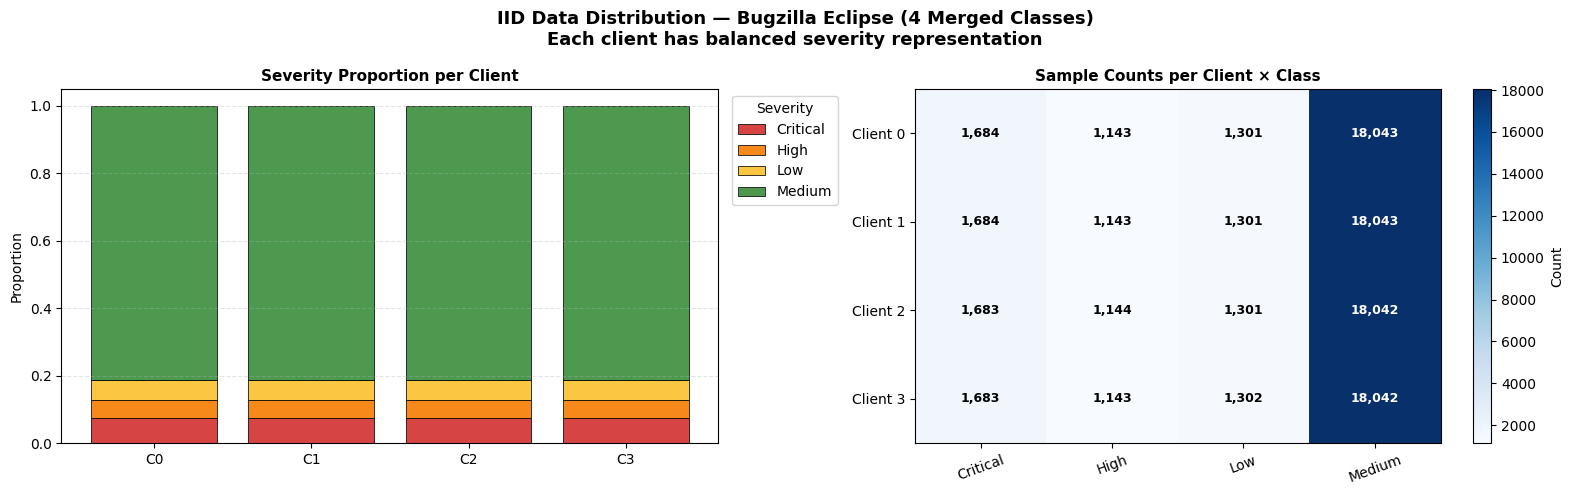

client_distribution_iid_ieee.png saved


In [ ]:
# ── Cell 8: Visualise IID Distribution ──────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

palette = ['#D32F2F', '#F57C00', '#FBC02D', '#388E3C']

counts_mat = np.zeros((NUM_CLIENTS, NUM_CLASSES), dtype=int)

for cid, split in enumerate(client_data):
    for lb in np.concatenate([split['y_train'], split['y_test']]):
        counts_mat[cid, int(lb)] += 1

props = counts_mat / counts_mat.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(
    'IID Data Distribution — Bugzilla Eclipse (4 Merged Classes)\nEach client has balanced severity representation',
    fontsize=13, fontweight='bold'
)

ax = axes[0]
bottom = np.zeros(NUM_CLIENTS)

for ci, cn in enumerate(class_names):
    ax.bar(
        [f'C{i}' for i in range(NUM_CLIENTS)], props[:, ci],
        bottom=bottom, label=cn, color=palette[ci], alpha=0.9, edgecolor='black', linewidth=0.6
    )
    bottom += props[:, ci]

ax.set_title('Severity Proportion per Client', fontsize=11, fontweight='bold')
ax.set_ylabel('Proportion')
ax.set_ylim(0, 1.05)
ax.grid(axis='y', linestyle='--', alpha=0.35)
ax.legend( title='Severity', bbox_to_anchor=(1.01, 1), frameon=True)

im = axes[1].imshow(counts_mat, cmap='Blues', aspect='auto')

axes[1].set_xticks(range(NUM_CLASSES))
axes[1].set_xticklabels(class_names, rotation=20)

axes[1].set_yticks(range(NUM_CLIENTS))
axes[1].set_yticklabels([f'Client {i}' for i in range(NUM_CLIENTS)])
axes[1].set_title( 'Sample Counts per Client × Class', fontsize=11, fontweight='bold')

for i in range(NUM_CLIENTS):
    for j in range(NUM_CLASSES):
        axes[1].text(j, i, f'{counts_mat[i,j]:,}', ha='center', va='center', fontsize=9, fontweight='bold',
            color='white' if counts_mat[i,j] > counts_mat.max()*0.55 else 'black'
        )

cbar = plt.colorbar(im, ax=axes[1])
cbar.set_label('Count')

plt.tight_layout()
plt.savefig('client_distribution_iid_ieee.png', dpi=300, bbox_inches='tight')
plt.show()
print("client_distribution_iid_ieee.png saved")

---
## Section 6 — MLP Model

In [ ]:
# ── Cell 9: PyTorch Dataset & MLP Model ──────────────────────────────────────
import torch.nn.functional as F

#This creates a custom dataset for PyTorch
class BugDataset(torch.utils.data.Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]


class ResidualBlock(nn.Module):
    """Linear → BN → GELU → Dropout  with skip projection."""
    def __init__(self, in_dim, out_dim, dropout=0.35):
        super().__init__()
        self.linear = nn.Linear(in_dim, out_dim)
        self.bn     = nn.BatchNorm1d(out_dim)
        self.act    = nn.GELU()
        self.drop   = nn.Dropout(dropout)
        self.proj   = nn.Linear(in_dim, out_dim, bias=False) if in_dim != out_dim else nn.Identity()

    def forward(self, x):
        return self.act(self.bn(self.linear(x))) + self.proj(x)


class BugSeverityMLP(nn.Module):
    """
    MLP on TF-IDF + categorical combined features.
    Architecture: input_bn → [512] → [512→256 residual] → [256→128 residual] → FC
    """
    def __init__(self, input_dim, num_classes, dropout=0.35):
        super().__init__()
        self.input_bn = nn.BatchNorm1d(input_dim)
        self.block1   = nn.Sequential(
            nn.Linear(input_dim, 512), nn.BatchNorm1d(512), nn.GELU(), nn.Dropout(dropout))
        self.res1     = ResidualBlock(512, 256, dropout)
        self.res2     = ResidualBlock(256, 128, dropout * 0.7)
        self.head     = nn.Linear(128, num_classes)
        self._init()

    def _init(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.input_bn(x)
        x = self.block1(x)
        x = self.res1(x)
        x = self.res2(x)
        return self.head(x)


def create_model():
    return BugSeverityMLP(INPUT_DIM, NUM_CLASSES, dropout=0.35).to(DEVICE)

def get_params(model):
    return [p.detach().cpu().numpy() for p in model.parameters()]

def set_params(model, params):
    with torch.no_grad():
        for p, v in zip(model.parameters(), params):
            p.copy_(torch.tensor(v, dtype=p.dtype).to(DEVICE))

#Model Testing
_m = create_model()
n_params = sum(p.numel() for p in _m.parameters())
_x = torch.randn(4, INPUT_DIM).to(DEVICE)
_o = _m(_x)
del _m
print(f"BugSeverityMLP (TF-IDF + residual MLP)")
print(f"Input dim  : {INPUT_DIM}  ({TFIDF_MAX_FEATURES} TF-IDF + {INPUT_DIM-TFIDF_MAX_FEATURES} categorical OHE)")
print(f"Output dim : {NUM_CLASSES}  ({class_names})")
print(f"Parameters : {n_params:,}  (vs 3.4M for BiLSTM — 10x fewer, faster convergence)")

BugSeverityMLP (TF-IDF + residual MLP)
Input dim  : 5008  (5000 TF-IDF + 8 categorical OHE)
Output dim : 4  (['Critical', 'High', 'Low', 'Medium'])
Parameters : 2,904,996  (vs 3.4M for BiLSTM — 10x fewer, faster convergence)


---
## Section 7 — LR Schedule - Warmup + Cosine

In [ ]:
# ── Cell 10: LR Schedule — Warmup + Cosine (min_lr > 0) ─────────────────────
def get_lr(fl_round: int) -> float:
    """
    Linear warmup for warmup_rounds, then cosine decay to MIN_LR (never 0).
    """
    if fl_round <= WARMUP_ROUNDS:
        return LEARNING_RATE * (fl_round / WARMUP_ROUNDS)
    progress = (fl_round - WARMUP_ROUNDS) / max(NUM_FL_ROUNDS - WARMUP_ROUNDS, 1)
    cosine   = 0.5 * (1.0 + math.cos(math.pi * progress))
    return MIN_LR + (LEARNING_RATE - MIN_LR) * cosine

print("LR schedule across FL rounds (min_lr fixed to never reach 0):")
for r in range(1, NUM_FL_ROUNDS + 1):
    lr  = get_lr(r)
    bar = '█' * max(1, int(lr / LEARNING_RATE * 30))
    tag = ' ← warmup' if r <= WARMUP_ROUNDS else (' ← peak' if r == WARMUP_ROUNDS+1 else '')
    print(f"  Round {r:>2}: {lr:.2e}  {bar}{tag}")

LR schedule across FL rounds (min_lr fixed to never reach 0):
  Round  1: 1.67e-04  ██████████ ← warmup
  Round  2: 3.33e-04  ████████████████████ ← warmup
  Round  3: 5.00e-04  ██████████████████████████████ ← warmup
  Round  4: 4.99e-04  █████████████████████████████ ← peak
  Round  5: 4.95e-04  █████████████████████████████
  Round  6: 4.89e-04  █████████████████████████████
  Round  7: 4.81e-04  ████████████████████████████
  Round  8: 4.71e-04  ████████████████████████████
  Round  9: 4.59e-04  ███████████████████████████
  Round 10: 4.44e-04  ██████████████████████████
  Round 11: 4.28e-04  █████████████████████████
  Round 12: 4.10e-04  ████████████████████████
  Round 13: 3.91e-04  ███████████████████████
  Round 14: 3.70e-04  ██████████████████████
  Round 15: 3.49e-04  ████████████████████
  Round 16: 3.26e-04  ███████████████████
  Round 17: 3.03e-04  ██████████████████
  Round 18: 2.79e-04  ████████████████
  Round 19: 2.55e-04  ███████████████
  Round 20: 2.31e-04  ███████

---
## Section 8 — Training & Evaluation Helpers

In [ ]:
# ── Cell 11: Training & Evaluation Helpers ───────────────────────────────────

def train_fedprox(model, loader, global_params, mu, optimizer, criterion, n_epochs):
    total_loss, total_n = 0.0, 0
    for _ in range(n_epochs):
        model.train()
        for Xb, yb in loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits  = model(Xb)
            ce_loss = criterion(logits, yb)
            prox    = sum(((lp - gp.to(DEVICE))**2).sum()
                         for lp, gp in zip(model.parameters(), global_params))
            loss    = ce_loss + (mu / 2) * prox
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item() * len(yb)
            total_n    += len(yb)
    return total_loss / max(total_n, 1)


def evaluate_model(model, loader, criterion):
    model.eval()
    preds, labels, total_loss = [], [], 0.0
    with torch.no_grad():
        for Xb, yb in loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            logits      = model(Xb)
            total_loss += criterion(logits, yb).item() * len(yb)
            preds.extend(logits.argmax(1).cpu().numpy())
            labels.extend(yb.cpu().numpy())
    n = len(labels)
    return (total_loss / max(n,1),
            accuracy_score(labels, preds),
            f1_score(labels, preds, average='weighted', zero_division=0))


print("train_fedprox() and evaluate_model() defined")

train_fedprox() and evaluate_model() defined


---
## Section 9 — Flower NumPyClient

In [ ]:
# ── Cell 12: Flower NumPyClient ──────────────────────────────────────────────
class BugSeverityClient(fl.client.NumPyClient):

    def __init__(self, cid: int, data: Dict):
        self.cid   = cid
        self.model = create_model()

        counts = np.bincount(data['y_train'], minlength=NUM_CLASSES)
        counts = np.where(counts == 0, 1, counts)
        w = torch.tensor(1.0/(counts/counts.sum()), dtype=torch.float32).to(DEVICE)
        w = w / w.sum() * NUM_CLASSES
        self.criterion = nn.CrossEntropyLoss(weight=w, label_smoothing=0.1)

        tr_ds = BugDataset(data['X_train'], data['y_train'])
        te_ds = BugDataset(data['X_test'],  data['y_test'])
        self.tr_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=False)
        self.te_loader = DataLoader(te_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
        self.n_train   = len(tr_ds)
        self.n_test    = len(te_ds)

        # created ONCE, persists across all FL rounds
        self.optimizer = torch.optim.AdamW(
            self.model.parameters(), lr=LEARNING_RATE,
            weight_decay=1e-4, betas=(0.9, 0.999))

    def get_parameters(self, config):
        return get_params(self.model)

    def fit(self, parameters, config):
        set_params(self.model, parameters)
        global_params = [p.clone().detach() for p in self.model.parameters()]

        # global LR schedule, never decays to 0
        fl_round = config.get('fl_round', 1)
        lr = get_lr(fl_round)
        for pg in self.optimizer.param_groups:
            pg['lr'] = lr

        mu       = config.get('proximal_mu', PROXIMAL_MU)
        avg_loss = train_fedprox(self.model, self.tr_loader, global_params,
                                 mu, self.optimizer, self.criterion, LOCAL_EPOCHS)
        _, tr_acc, tr_f1 = evaluate_model(self.model, self.tr_loader, self.criterion)
        return get_params(self.model), self.n_train, {
            'train_loss': float(avg_loss),
            'accuracy'  : float(tr_acc),
            'f1'        : float(tr_f1),
            'lr'        : lr,
        }

    def evaluate(self, parameters, config):
        set_params(self.model, parameters)
        loss, acc, f1 = evaluate_model(self.model, self.te_loader, self.criterion)
        return float(loss), self.n_test, {'accuracy': float(acc), 'f1': float(f1)}


print("BugSeverityClient defined (persistent optimizer + global LR + label smoothing)")

BugSeverityClient defined (persistent optimizer + global LR + label smoothing)


---
## Section 10 — FedAvg Aggregation

In [ ]:
# ── Cell 13: FedAvg Aggregation ──────────────────────────────────────────────
def fedavg_aggregate(results):
    total_n = sum(n for _, n in results)
    return [sum((n/total_n)*p for p, n in zip(layer, [n for _, n in results]))
            for layer in zip(*[params for params, _ in results])]

print("FedAvg aggregation defined  (w_global = Σ (n_i/N) · w_i)")

FedAvg aggregation defined  (w_global = Σ (n_i/N) · w_i)


---
## Section 11 — FL Simulation

In [ ]:
# ── Cell 14: FL Simulation ───────────────────────────────────────────────────
print("=" * 65)
print("  STEP 5: Running FL Simulation — IID / Bugzilla Eclipse (v3)")
print("=" * 65)
print(f"  Dataset     : Bugzilla Eclipse Bug Reports")
print(f"  Classes     : {NUM_CLASSES}  {class_names}")
print(f"  Clients     : {NUM_CLIENTS} (IID — uniform homogeneous)")
print(f"  Rounds      : {NUM_FL_ROUNDS}  |  Local epochs: {LOCAL_EPOCHS}")
print(f"  LR schedule : warmup({WARMUP_ROUNDS} rounds) + cosine → min {MIN_LR:.0e}")
print(f"  Model       : BugSeverityMLP (TF-IDF {TFIDF_MAX_FEATURES}d + OHE → residual MLP)")
print(f"  FedProx μ   : {PROXIMAL_MU}")
print(f"  Device      : {DEVICE}")
print()

clients       = [BugSeverityClient(cid, client_data[cid]) for cid in range(NUM_CLIENTS)]
global_model  = create_model()
global_params = get_params(global_model)
round_log     = []
acc_list, f1_list, loss_list = [], [], []

for fl_round in range(1, NUM_FL_ROUNDS + 1):
    config = {'fl_round': fl_round, 'proximal_mu': PROXIMAL_MU}

    fit_results = []
    for client in clients:
        updated, n_samples, _ = client.fit(copy.deepcopy(global_params), config)
        fit_results.append((updated, n_samples))

    global_params = fedavg_aggregate(fit_results)

    eval_results = []
    for client in clients:
        loss, n_test, metrics = client.evaluate(copy.deepcopy(global_params), config)
        eval_results.append((loss, n_test, metrics))

    total_test = sum(n for _, n, _ in eval_results)
    avg_acc  = sum((n/total_test)*m['accuracy'] for _, n, m in eval_results)
    avg_f1   = sum((n/total_test)*m['f1']       for _, n, m in eval_results)
    avg_loss = sum((n/total_test)*l             for l, n, _ in eval_results)
    per_acc  = [m['accuracy'] for _, _, m in eval_results]
    cur_lr   = get_lr(fl_round)

    acc_list.append(avg_acc);  f1_list.append(avg_f1);  loss_list.append(avg_loss)
    round_log.append({'round': fl_round, 'avg_accuracy': avg_acc,
                      'avg_f1': avg_f1,  'avg_loss': avg_loss,
                      'per_client_acc': per_acc})

    print(f"  Round {fl_round:>2}/{NUM_FL_ROUNDS} | "
          f"Acc={avg_acc:.4f} | F1={avg_f1:.4f} | Loss={avg_loss:.4f} | "
          f"LR={cur_lr:.2e} | Clients: {[f'{a:.3f}' for a in per_acc]}")

set_params(global_model, global_params)
print()
print("Federated Learning simulation complete!")
print(f"Best accuracy : {max(acc_list):.4f}")
print(f"Best F1       : {max(f1_list):.4f}")

  STEP 5: Running FL Simulation — IID / Bugzilla Eclipse (v3)
  Dataset     : Bugzilla Eclipse Bug Reports
  Classes     : 4  ['Critical', 'High', 'Low', 'Medium']
  Clients     : 4 (IID — uniform homogeneous)
  Rounds      : 35  |  Local epochs: 8
  LR schedule : warmup(3 rounds) + cosine → min 1e-05
  Model       : BugSeverityMLP (TF-IDF 5000d + OHE → residual MLP)
  FedProx μ   : 0.01
  Device      : cuda

  Round  1/35 | Acc=0.3985 | F1=0.4820 | Loss=2.5776 | LR=1.67e-04 | Clients: ['0.375', '0.400', '0.420', '0.399']
  Round  2/35 | Acc=0.5439 | F1=0.6095 | Loss=2.3658 | LR=3.33e-04 | Clients: ['0.546', '0.539', '0.554', '0.537']
  Round  3/35 | Acc=0.5547 | F1=0.6182 | Loss=2.2173 | LR=5.00e-04 | Clients: ['0.545', '0.563', '0.565', '0.546']
  Round  4/35 | Acc=0.4826 | F1=0.5648 | Loss=2.1338 | LR=4.99e-04 | Clients: ['0.489', '0.458', '0.499', '0.484']
  Round  5/35 | Acc=0.5541 | F1=0.6240 | Loss=2.1101 | LR=4.95e-04 | Clients: ['0.557', '0.547', '0.573', '0.539']
  Round  6/3

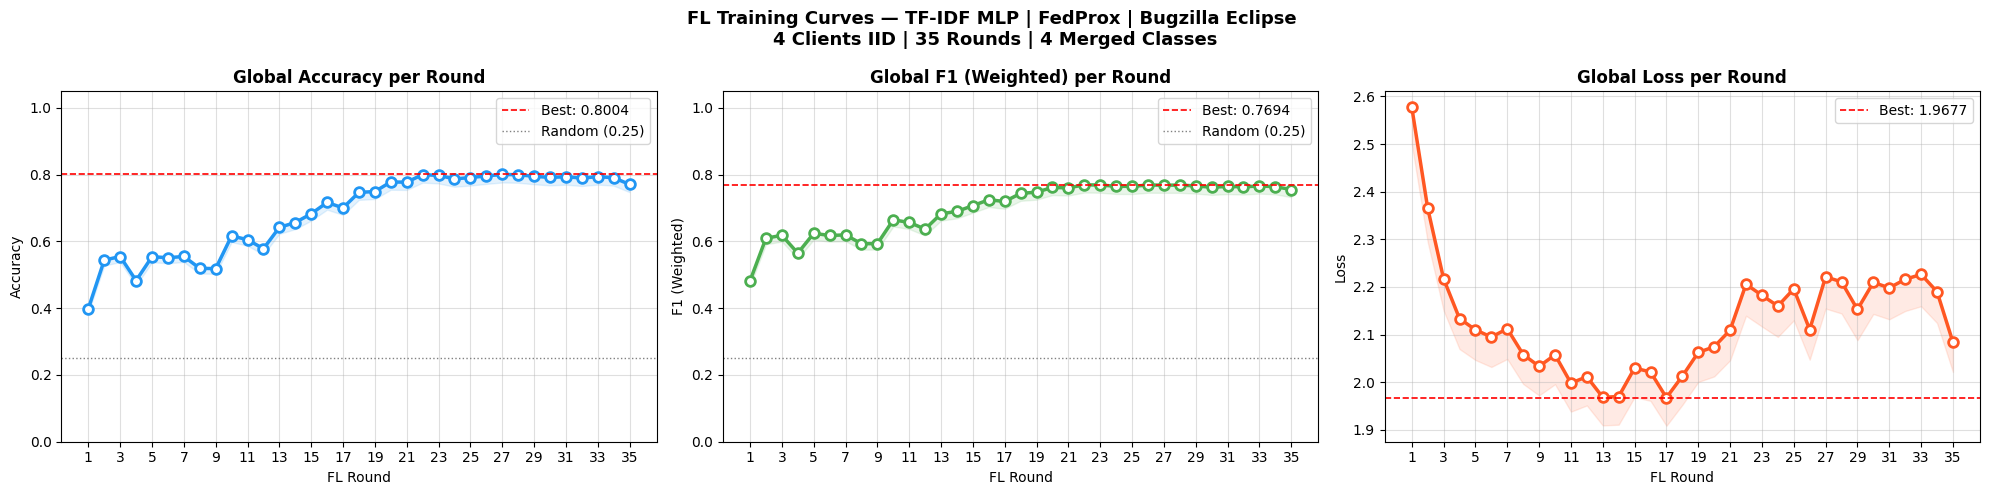

fl_training_curves_v3.png saved


In [ ]:
# ── Cell 15: FL Training Curves ──────────────────────────────────────────────
rounds_list = list(range(1, NUM_FL_ROUNDS + 1))
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle(
    f'FL Training Curves — TF-IDF MLP | FedProx | Bugzilla Eclipse \n'
    f'{NUM_CLIENTS} Clients IID | {NUM_FL_ROUNDS} Rounds | {NUM_CLASSES} Merged Classes',
    fontsize=13, fontweight='bold')

for ax, vals, color, ylabel, bfn in [
    (axes[0], acc_list,  '#2196F3', 'Accuracy', max),
    (axes[1], f1_list,   '#4CAF50', 'F1 (Weighted)', max),
    (axes[2], loss_list, '#FF5722', 'Loss', min)]:
    ax.plot(rounds_list, vals, 'o-', color=color, lw=2.5, ms=7,
            markerfacecolor='white', markeredgewidth=2)
    ax.fill_between(rounds_list, [v*0.97 for v in vals], vals, alpha=0.12, color=color)
    ax.axhline(bfn(vals), color='red', lw=1.2, ls='--', label=f'Best: {bfn(vals):.4f}')
    if ylabel != 'Loss':
        ax.axhline(1/NUM_CLASSES, color='gray', lw=1, ls=':', label=f'Random ({1/NUM_CLASSES:.2f})')
    ax.set_xlabel('FL Round'); ax.set_ylabel(ylabel)
    if ylabel != 'Loss': ax.set_ylim(0, 1.05)
    ax.set_title(f'Global {ylabel} per Round', fontweight='bold')
    ax.legend(); ax.grid(alpha=0.4); ax.set_xticks(rounds_list[::2])

plt.tight_layout()
plt.savefig('fl_training_curves_v3.png', dpi=120, bbox_inches='tight')
plt.show()
print("fl_training_curves_v3.png saved")

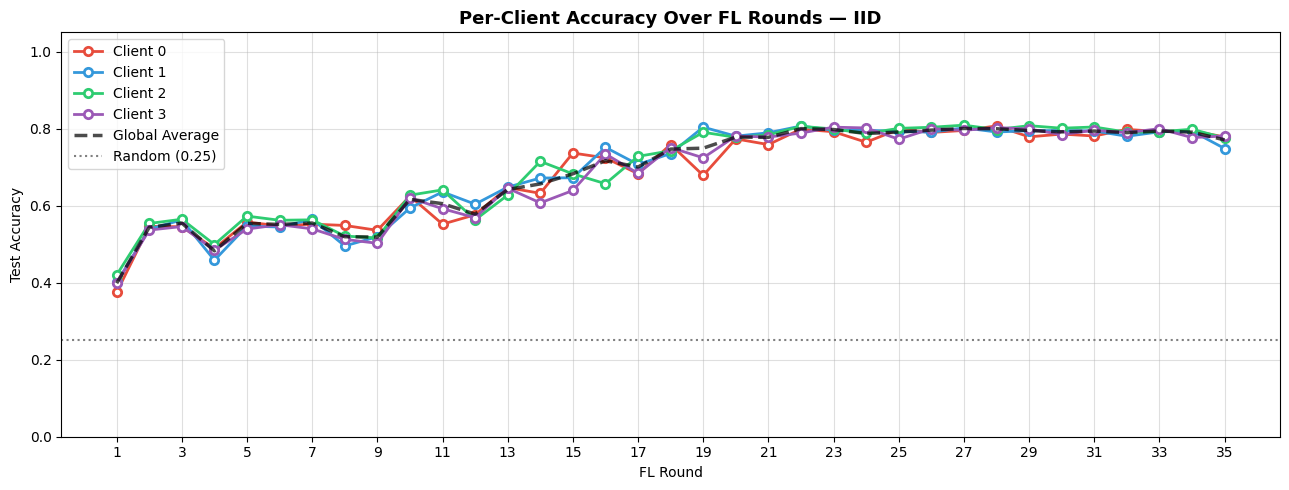

per_client_accuracy_v3.png saved


In [ ]:
# ── Cell 16: Per-Client Accuracy ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
colors = ['#e74c3c','#3498db','#2ecc71','#9b59b6']
for cid in range(NUM_CLIENTS):
    per_c = [m['per_client_acc'][cid] for m in round_log]
    ax.plot(rounds_list, per_c, 'o-', color=colors[cid], lw=2,
            label=f'Client {cid}', ms=6, markerfacecolor='white', markeredgewidth=2)
ax.plot(rounds_list, acc_list, 'k--', lw=2.5, label='Global Average', alpha=0.7)
ax.axhline(1/NUM_CLASSES, color='gray', lw=1.5, ls=':', label=f'Random ({1/NUM_CLASSES:.2f})')
ax.set_title('Per-Client Accuracy Over FL Rounds — IID', fontsize=13, fontweight='bold')
ax.set_xlabel('FL Round'); ax.set_ylabel('Test Accuracy')
ax.set_ylim(0, 1.05); ax.legend(); ax.grid(alpha=0.4); ax.set_xticks(rounds_list[::2])
plt.tight_layout()
plt.savefig('per_client_accuracy_v3.png', dpi=120, bbox_inches='tight')
plt.show()
print("per_client_accuracy_v3.png saved")

In [ ]:
# ── Cell 17: Centralised Baseline ────────────────────────────────────────────
print("Training centralised baseline (same MLP on all data)...")
from torch.utils.data import ConcatDataset

X_tr_all = np.concatenate([s['X_train'] for s in client_data])
y_tr_all = np.concatenate([s['y_train'] for s in client_data])
X_te_all = np.concatenate([s['X_test']  for s in client_data])
y_te_all = np.concatenate([s['y_test']  for s in client_data])

c_ld_tr  = DataLoader(BugDataset(X_tr_all, y_tr_all), batch_size=256, shuffle=True)
c_ld_te  = DataLoader(BugDataset(X_te_all, y_te_all), batch_size=256, shuffle=False)

central  = create_model()
c_crit   = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
c_optim  = torch.optim.AdamW(central.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
dummy_gp = [p.clone().detach() for p in central.parameters()]
total_ep = NUM_FL_ROUNDS * LOCAL_EPOCHS

for ep in range(total_ep):
    fl_eq  = int(ep / LOCAL_EPOCHS) + 1
    cur_lr = get_lr(fl_eq)
    for pg in c_optim.param_groups: pg['lr'] = cur_lr
    train_fedprox(central, c_ld_tr, dummy_gp, 0.0, c_optim, c_crit, 1)
    if (ep+1) % 25 == 0:
        _, acc, f1 = evaluate_model(central, c_ld_te, c_crit)
        print(f"  Epoch {ep+1:>3}/{total_ep} → Acc={acc:.4f} | F1={f1:.4f}")

_, central_acc, central_f1 = evaluate_model(central, c_ld_te, c_crit)
fl_final_acc, fl_final_f1  = acc_list[-1], f1_list[-1]

print(f"\nCentralised | Acc={central_acc:.4f} | F1={central_f1:.4f}")
print(f"FL Round {NUM_FL_ROUNDS:>2}  | Acc={fl_final_acc:.4f} | F1={fl_final_f1:.4f}")

Training centralised baseline (same MLP on all data)...
  Epoch  25/280 → Acc=0.4303 | F1=0.5189
  Epoch  50/280 → Acc=0.5055 | F1=0.5900
  Epoch  75/280 → Acc=0.6971 | F1=0.7291
  Epoch 100/280 → Acc=0.7282 | F1=0.7484
  Epoch 125/280 → Acc=0.7331 | F1=0.7502
  Epoch 150/280 → Acc=0.7386 | F1=0.7534
  Epoch 175/280 → Acc=0.7387 | F1=0.7521
  Epoch 200/280 → Acc=0.7372 | F1=0.7501
  Epoch 225/280 → Acc=0.7324 | F1=0.7482
  Epoch 250/280 → Acc=0.7355 | F1=0.7493
  Epoch 275/280 → Acc=0.7376 | F1=0.7501

Centralised | Acc=0.7357 | F1=0.7487
FL Round 35  | Acc=0.7708 | F1=0.7553


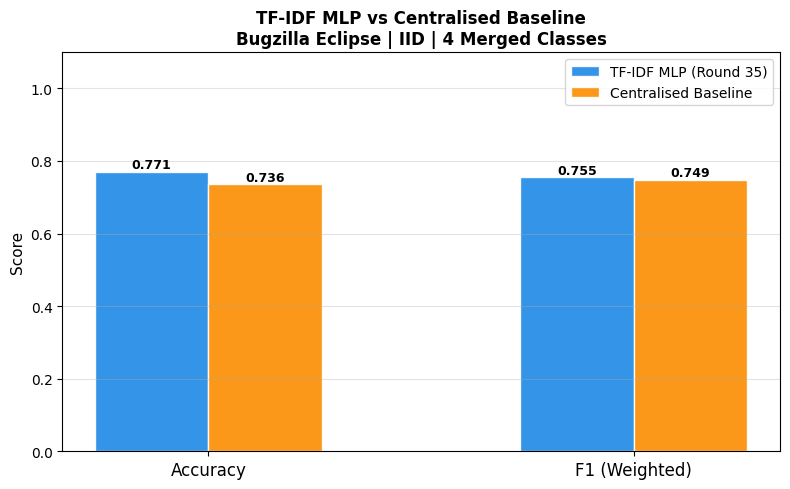

comparison_TF-IDF-MLP_centralized.png saved


In [ ]:
# ── Cell 18: FL vs Centralised Bar Chart ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

# Reduce spacing between groups
x = np.array([0, 0.9])
w = 0.24

b1 = ax.bar(x - w/2, [fl_final_acc, fl_final_f1], w,
            label=f'TF-IDF MLP (Round {NUM_FL_ROUNDS})',
            color='#1E88E5', alpha=0.9, edgecolor='white')

b2 = ax.bar(x + w/2, [central_acc, central_f1], w,
            label='Centralised Baseline',
            color='#FB8C00', alpha=0.9, edgecolor='white')

for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.3f}',
            ha='center', fontsize=9, fontweight='bold')

ax.set_title('TF-IDF MLP vs Centralised Baseline\n'
             f'Bugzilla Eclipse | IID | {NUM_CLASSES} Merged Classes',
             fontsize=12, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(['Accuracy', 'F1 (Weighted)'], fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score', fontsize=11)

ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.35)

plt.tight_layout()
plt.savefig('comparison_TF-IDF-MLP_centralized.png', dpi=300, bbox_inches='tight')
plt.show()
print("comparison_TF-IDF-MLP_centralized.png saved")

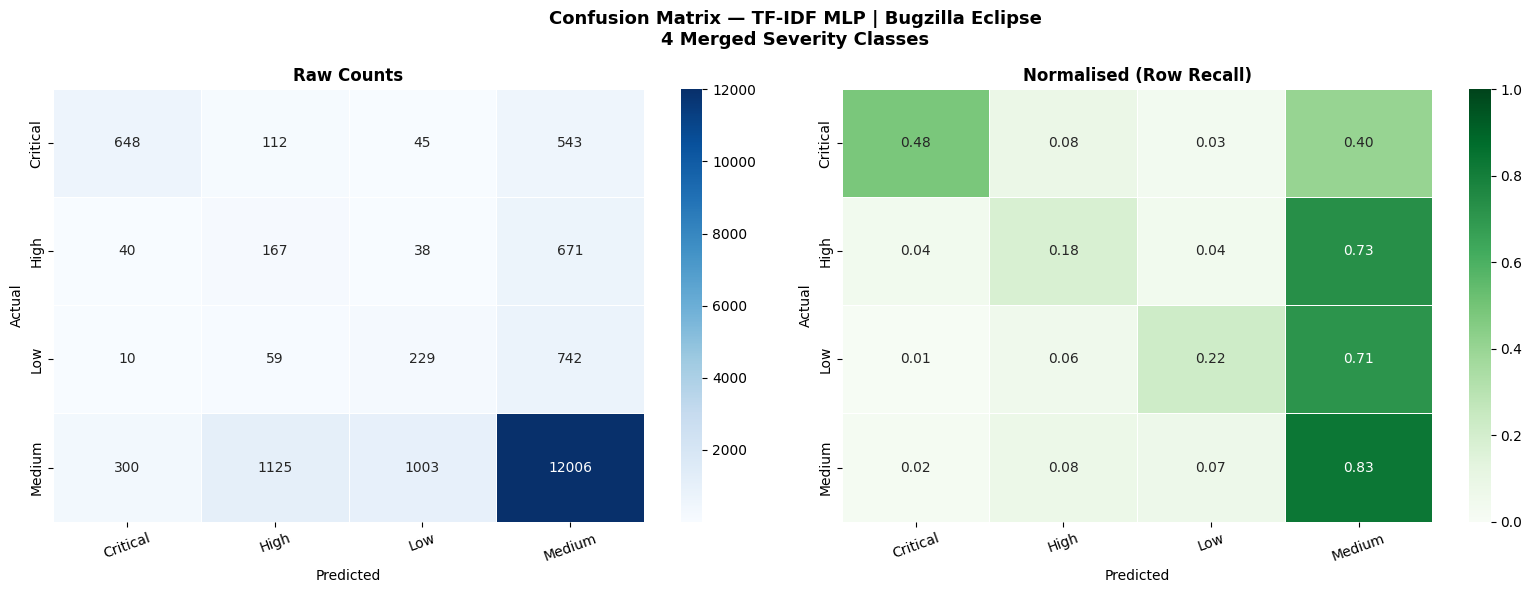

confusion_matrix_v3.png saved


In [ ]:
# ── Cell 19: Confusion Matrix ────────────────────────────────────────────────
central.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for Xb, yb in c_ld_te:
        logits = central(Xb.to(DEVICE))
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(yb.numpy())

cm      = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Confusion Matrix — TF-IDF MLP | Bugzilla Eclipse\n'
             '4 Merged Severity Classes', fontsize=13, fontweight='bold')

for ax, data, fmt, cmap, title in [
    (axes[0], cm,      'd',   'Blues',  'Raw Counts'),
    (axes[1], cm_norm, '.2f', 'Greens', 'Normalised (Row Recall)')]:
    sns.heatmap(data, annot=True, fmt=fmt, cmap=cmap, ax=ax,
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5, vmin=(0 if fmt=='.2f' else None),
                vmax=(1 if fmt=='.2f' else None))
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('confusion_matrix_v3.png', dpi=120, bbox_inches='tight')
plt.show()
print("confusion_matrix_v3.png saved")